# Train AutoTransformer For CAMELS QObs Prediction

This notebook trains one shared AutoTransformer-style model across CAMELS basins to predict runoff `QObs(mm/day)` from meteorological forcing features.

Protocol:

- one shared model for all selected basins
- input lookback window: 365 days
- prediction horizon: 1 day
- independent holdout period: 2008-01-01 to 2014-12-31
- expanding-window cross-validation on pre-2008 years for hyperparameter tuning
- random search for hyperparameter tuning
- final training on all pre-2008 windows
- final evaluation on 2008-2014 holdout

Main difference from the vanilla transformer baseline:

- Vanilla Transformer treats days as temporal tokens: `(batch, 365, features)`
- iTransformer treats variables as tokens: `(batch, variables, 365)`
- `basin_code` is handled as a categorical embedding token rather than a continuous feature

## Dependencies

The notebook was tested with the local `cs7643` environment. Core packages:

```bash
pip install numpy pandas pyarrow torch matplotlib tqdm
```

In [1]:
from __future__ import annotations

import copy
import json
import math
import random
import time
from bisect import bisect_right
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import math
from torch.utils.data import DataLoader, Dataset, Subset

## Configuration

Edit this cell before running the notebook.

Main controls:

- `BASIN_IDS`: leave empty to use all basins in the processed file
- `LOOKBACK_DAYS`: input sequence length
- `PREDICTION_HORIZON_DAYS`: number of days ahead to predict
- `INDEPENDENT_VAL_START` and `INDEPENDENT_VAL_END`: fixed holdout period
- `CV_NUM_FOLDS`: number of expanding-window folds on years before the holdout period
- `SEARCH_TRIALS`: random-search budget for hyperparameter tuning

In [2]:
from __future__ import annotations

import copy
import json
import math
import random
import time
from bisect import bisect_right
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset


CONFIG = {
    # Local Windows path
    "DATA_DIR": r"C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\processed",
    "JOINED_FILENAME_PREFERENCE": [
        "camels_transformer_joined.parquet",
        "camels_transformer_joined.csv",
    ],
    "METADATA_FILENAME": "camels_transformer_metadata.json",

    "OUTPUT_DIR": r"C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts",
    "RUN_NAME": "autotransformer_default",

    # Data/task setup
    "BASIN_IDS": [],
    "LOOKBACK_DAYS": 365,
    "PREDICTION_HORIZON_DAYS": 1,
    "USE_ALL_FEATURES": True,

    # Independent holdout period
    "INDEPENDENT_VAL_START": "2008-01-01",
    "INDEPENDENT_VAL_END": "2014-12-31",

    # Expanding-window CV
    "CV_NUM_FOLDS": 4,

    # Runtime
    "SEED": 7643,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",

    # On Windows, keep NUM_WORKERS = 0 first. Increase later if stable.
    "NUM_WORKERS": 0,
    "PIN_MEMORY": True,


    # "SEARCH_TRIALS": 1,
    # "SEARCH_EPOCHS": 1,
    # "SEARCH_PATIENCE": 1,
    # "FINAL_MAX_EPOCHS": 1,
    # "TUNING_MAX_TRAIN_WINDOWS": 2000,
    # "TUNING_MAX_VAL_WINDOWS": 1000,


    "SEARCH_TRIALS": 8,
    "SEARCH_EPOCHS": 10,
    "SEARCH_PATIENCE": 2,
    "FINAL_MAX_EPOCHS": 20,
    "TUNING_MAX_TRAIN_WINDOWS": 50000,
    "TUNING_MAX_VAL_WINDOWS": 15000,

    "SAVE_CHECKPOINTS": True,
}

CONFIG["RUN_DIR"] = str(Path(CONFIG["OUTPUT_DIR"]) / CONFIG["RUN_NAME"])
Path(CONFIG["RUN_DIR"]).mkdir(parents=True, exist_ok=True)

CONFIG

{'DATA_DIR': 'C:\\Users\\Xiaoya\\Documents\\Jiahao\\CAMELS_data_load\\CAMELS_data_load\\processed',
 'JOINED_FILENAME_PREFERENCE': ['camels_transformer_joined.parquet',
  'camels_transformer_joined.csv'],
 'METADATA_FILENAME': 'camels_transformer_metadata.json',
 'OUTPUT_DIR': 'C:\\Users\\Xiaoya\\Documents\\Jiahao\\CAMELS_data_load\\CAMELS_data_load\\model_artifacts',
 'RUN_NAME': 'autotransformer_default',
 'BASIN_IDS': [],
 'LOOKBACK_DAYS': 365,
 'PREDICTION_HORIZON_DAYS': 1,
 'USE_ALL_FEATURES': True,
 'INDEPENDENT_VAL_START': '2008-01-01',
 'INDEPENDENT_VAL_END': '2014-12-31',
 'CV_NUM_FOLDS': 4,
 'SEED': 7643,
 'DEVICE': 'cuda',
 'NUM_WORKERS': 0,
 'PIN_MEMORY': True,
 'SEARCH_TRIALS': 8,
 'SEARCH_EPOCHS': 10,
 'SEARCH_PATIENCE': 2,
 'FINAL_MAX_EPOCHS': 20,
 'TUNING_MAX_TRAIN_WINDOWS': 50000,
 'TUNING_MAX_VAL_WINDOWS': 15000,
 'SAVE_CHECKPOINTS': True,
 'RUN_DIR': 'C:\\Users\\Xiaoya\\Documents\\Jiahao\\CAMELS_data_load\\CAMELS_data_load\\model_artifacts\\autotransformer_default'}

## Hyperparameter Search Space

This notebook uses random search over a bounded search space rather than exhaustive grid search.

In [3]:
SEARCH_SPACE = {
    "d_model": [64, 96],
    "nhead": [4],
    "num_layers": [1, 2],
    "dim_feedforward": [128, 256],
    "dropout": [0.05, 0.10],
    "moving_avg_kernel": [7, 15, 25],
    "learning_rate": [2e-4, 3e-4],
    "weight_decay": [0.0, 1e-5],
    "batch_size": [16],
}

SEARCH_SPACE

{'d_model': [64, 96],
 'nhead': [4],
 'num_layers': [1, 2],
 'dim_feedforward': [128, 256],
 'dropout': [0.05, 0.1],
 'moving_avg_kernel': [7, 15, 25],
 'learning_rate': [0.0002, 0.0003],
 'weight_decay': [0.0, 1e-05],
 'batch_size': [16]}

## Helpers

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def load_metadata(config: Dict) -> Dict:
    metadata_path = Path(config["DATA_DIR"]) / config["METADATA_FILENAME"]
    return json.loads(metadata_path.read_text(encoding="utf-8"))


def choose_joined_path(config: Dict) -> Path:
    data_dir = Path(config["DATA_DIR"])

    for filename in config["JOINED_FILENAME_PREFERENCE"]:
        path = data_dir / filename
        if path.exists():
            return path

    raise FileNotFoundError("Could not find a joined CAMELS file in processed/.")


def read_joined_table(config: Dict, metadata: Dict) -> pd.DataFrame:
    joined_path = choose_joined_path(config)

    feature_columns = metadata["feature_columns"]
    target_column = metadata["target_column_in_joined_file"]

    columns = ["basin_id", "date"] + feature_columns + [target_column]

    if joined_path.suffix == ".parquet":
        df = pd.read_parquet(joined_path, columns=columns)
    else:
        df = pd.read_csv(joined_path, usecols=columns, parse_dates=["date"])

    df["basin_id"] = df["basin_id"].astype(str).str.zfill(8)
    df["date"] = pd.to_datetime(df["date"])

    return df.sort_values(["basin_id", "date"]).reset_index(drop=True)


def maybe_filter_basins(df: pd.DataFrame, basin_ids: Sequence[str]) -> pd.DataFrame:
    if not basin_ids:
        return df

    basin_ids = [str(x).zfill(8) for x in basin_ids]

    return df[df["basin_id"].isin(basin_ids)].copy()


def infer_feature_columns(metadata: Dict, config: Dict) -> List[str]:
    if not config["USE_ALL_FEATURES"]:
        raise ValueError("This notebook is configured to use all features.")

    return list(metadata["feature_columns"])


def global_nse(pred: np.ndarray, target: np.ndarray, eps: float = 1e-6) -> float:
    pred = pred.reshape(-1)
    target = target.reshape(-1)

    numerator = np.sum((pred - target) ** 2)
    denominator = np.sum((target - target.mean()) ** 2) + eps

    return float(1.0 - numerator / denominator)


def nse_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.reshape(-1)
    target = target.reshape(-1)

    numerator = torch.sum((pred - target) ** 2)
    denominator = torch.sum((target - torch.mean(target)) ** 2) + eps

    return numerator / denominator


def regression_metrics(pred: np.ndarray, target: np.ndarray) -> Dict[str, float]:
    pred = pred.reshape(-1)
    target = target.reshape(-1)

    rmse = float(np.sqrt(np.mean((pred - target) ** 2)))
    mae = float(np.mean(np.abs(pred - target)))
    nse = global_nse(pred, target)

    return {
        "rmse": rmse,
        "mae": mae,
        "nse": nse,
        "loss": 1.0 - nse,
    }


def sample_config(search_space: Dict[str, List], seen: set, rng: random.Random) -> Dict:
    keys = sorted(search_space)

    while True:
        candidate = {key: rng.choice(search_space[key]) for key in keys}

        if candidate["d_model"] % candidate["nhead"] != 0:
            continue

        signature = tuple((key, candidate[key]) for key in keys)

        if signature not in seen:
            seen.add(signature)
            return candidate

## Load Processed CAMELS Data

In [5]:
set_seed(CONFIG["SEED"])

metadata = load_metadata(CONFIG)

feature_columns = infer_feature_columns(metadata, CONFIG)
target_column = metadata["target_column_in_joined_file"]

# iTransformer-specific split:
# dynamic features exclude basin_code.
dynamic_feature_columns = [c for c in feature_columns if c != "basin_code"]
basin_code_column = "basin_code"

joined_df = read_joined_table(CONFIG, metadata)
joined_df = maybe_filter_basins(joined_df, CONFIG["BASIN_IDS"])

# Safety filter for invalid targets.
# This protects against old preprocessing where -999 cfs may become negative mm/day.
joined_df = joined_df.replace([-999, -999.0, -99, -99.0], np.nan)
joined_df = joined_df.dropna(subset=feature_columns + [target_column]).copy()

if target_column == "QObs(mm/day)":
    joined_df = joined_df[joined_df[target_column] >= 0].copy()

joined_df = joined_df.sort_values(["basin_id", "date"]).reset_index(drop=True)

num_basins = int(joined_df[basin_code_column].max()) + 1

print("Using joined file:", choose_joined_path(CONFIG))
print("Target column:", target_column)
print("All feature columns:", feature_columns)
print("Dynamic feature columns:", dynamic_feature_columns)
print("Basin code column:", basin_code_column)
print("Rows:", len(joined_df))
print("Basins:", joined_df["basin_id"].nunique())
print("Num basin codes:", num_basins)
print("Date range:", joined_df["date"].min().date(), "to", joined_df["date"].max().date())

joined_df.head()

Using joined file: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\processed\camels_transformer_joined.parquet
Target column: QObs(mm/day)
All feature columns: ['Dayl(s)', 'PRCP(mm/day)', 'SRAD(W/m2)', 'SWE(mm)', 'Tmax(C)', 'Tmin(C)', 'Vp(Pa)', 'doy_sin', 'doy_cos', 'basin_code']
Dynamic feature columns: ['Dayl(s)', 'PRCP(mm/day)', 'SRAD(W/m2)', 'SWE(mm)', 'Tmax(C)', 'Tmin(C)', 'Vp(Pa)', 'doy_sin', 'doy_cos']
Basin code column: basin_code
Rows: 8346008
Basins: 671
Num basin codes: 671
Date range: 1980-01-01 to 2014-12-31


,basin_id,date,Dayl(s),PRCP(mm/day),SRAD(W/m2),SWE(mm),Tmax(C),Tmin(C),Vp(Pa),doy_sin,doy_cos,basin_code,QObs(mm/day)
0,01013500,1980-01-01,30172.48,0.0,218.66,0.0,-13.04,-13.04,203.28,0.017166,0.999853,0,0.711372
1,01013500,1980-01-02,30253.07,0.0,199.05,0.0,-10.93,-10.93,237.37,0.034328,0.999411,0,0.695081
2,01013500,1980-01-03,30344.16,0.0,197.64,0.0,-13.60,-13.60,169.39,0.051479,0.998674,0,0.678790
3,01013500,1980-01-04,30408.34,0.0,214.61,0.0,-16.53,-16.53,134.57,0.068615,0.997643,0,0.673359
4,01013500,1980-01-05,30413.49,0.0,206.02,0.0,-17.60,-17.60,129.30,0.085731,0.996318,0,0.657068


## Build Basin Store + Time Protocol + Dataset


In [6]:
def build_basin_store(
    df: pd.DataFrame,
    dynamic_feature_columns: List[str],
    basin_code_column: str,
    target_column: str,
) -> Dict[str, Dict[str, np.ndarray]]:
    store = {}

    for basin_id, basin_df in df.groupby("basin_id", sort=True):
        basin_df = basin_df.sort_values("date").reset_index(drop=True)

        basin_code_values = basin_df[basin_code_column].unique()
        if len(basin_code_values) != 1:
            raise ValueError(
                f"Basin {basin_id} has multiple basin_code values: {basin_code_values}"
            )

        store[basin_id] = {
            "dynamic_features": basin_df[dynamic_feature_columns].to_numpy(dtype=np.float32),
            "basin_code": int(basin_code_values[0]),
            "target": basin_df[target_column].to_numpy(dtype=np.float32),
            "dates": basin_df["date"].to_numpy(),
        }

    return store


def eligible_target_indices(n_rows: int, lookback_days: int, horizon_days: int) -> np.ndarray:
    first_target_idx = lookback_days + horizon_days - 1

    if n_rows <= first_target_idx:
        return np.array([], dtype=np.int64)

    return np.arange(first_target_idx, n_rows, dtype=np.int64)


def year_chunks_for_expanding_cv(train_years: List[int], cv_num_folds: int) -> List[List[int]]:
    chunks = np.array_split(np.array(train_years), cv_num_folds + 1)

    return [chunk.astype(int).tolist() for chunk in chunks if len(chunk) > 0]


def build_time_protocol(
    basin_store: Dict[str, Dict[str, np.ndarray]],
    lookback_days: int,
    horizon_days: int,
    independent_val_start: str,
    independent_val_end: str,
    cv_num_folds: int,
) -> Dict:
    holdout_start = np.datetime64(independent_val_start)
    holdout_end = np.datetime64(independent_val_end)

    pre_holdout_years = sorted({
        int(pd.Timestamp(date_value).year)
        for basin_data in basin_store.values()
        for date_value in basin_data["dates"]
        if date_value < holdout_start
    })

    chunks = year_chunks_for_expanding_cv(pre_holdout_years, cv_num_folds)

    if len(chunks) < 2:
        raise ValueError("Not enough pre-holdout years to build CV folds.")

    cv_folds = []

    for fold_idx in range(len(chunks) - 1):
        train_years = sorted([year for chunk in chunks[: fold_idx + 1] for year in chunk])
        val_years = sorted(chunks[fold_idx + 1])

        if not train_years or not val_years:
            continue

        cv_folds.append({
            "fold_id": fold_idx,
            "train_years": train_years,
            "val_years": val_years,
        })

    basin_protocol = {}
    usable_basins = []

    for basin_id, basin_data in basin_store.items():
        dates = basin_data["dates"]

        target_indices = eligible_target_indices(
            len(dates),
            lookback_days,
            horizon_days,
        )

        if len(target_indices) == 0:
            continue

        target_dates = dates[target_indices]

        pre_holdout_mask = target_dates < holdout_start
        holdout_mask = (target_dates >= holdout_start) & (target_dates <= holdout_end)

        pre_holdout_targets = target_indices[pre_holdout_mask]
        holdout_targets = target_indices[holdout_mask]

        if len(holdout_targets) == 0:
            continue

        fold_targets = []
        valid_basin = True

        for fold in cv_folds:
            train_year_set = set(fold["train_years"])
            val_year_set = set(fold["val_years"])

            train_targets = np.array([
                idx
                for idx in pre_holdout_targets
                if int(pd.Timestamp(dates[idx]).year) in train_year_set
            ], dtype=np.int64)

            val_targets = np.array([
                idx
                for idx in pre_holdout_targets
                if int(pd.Timestamp(dates[idx]).year) in val_year_set
            ], dtype=np.int64)

            if len(train_targets) == 0 or len(val_targets) == 0:
                valid_basin = False
                break

            fold_targets.append({
                "fold_id": fold["fold_id"],
                "train_targets": train_targets,
                "val_targets": val_targets,
            })

        if not valid_basin:
            continue

        basin_protocol[basin_id] = {
            "cv_folds": fold_targets,
            "holdout_targets": holdout_targets,
            "pre_holdout_targets": pre_holdout_targets,
        }

        usable_basins.append(basin_id)

    return {
        "holdout_start": str(holdout_start),
        "holdout_end": str(holdout_end),
        "cv_folds": [
            {
                "fold_id": fold["fold_id"],
                "train_years": fold["train_years"],
                "val_years": fold["val_years"],
            }
            for fold in cv_folds
        ],
        "basin_protocol": basin_protocol,
        "usable_basins": usable_basins,
    }


class WindowedTargetDataset(Dataset):
    def __init__(
        self,
        basin_store: Dict[str, Dict[str, np.ndarray]],
        target_map: Dict[str, np.ndarray],
        lookback_days: int,
        horizon_days: int,
        feature_mean: np.ndarray,
        feature_std: np.ndarray,
    ):
        self.basin_store = basin_store
        self.lookback_days = lookback_days
        self.horizon_days = horizon_days
        self.feature_mean = feature_mean.astype(np.float32)
        self.feature_std = feature_std.astype(np.float32)

        self.entries = []
        self.cum_counts = []

        running = 0

        for basin_id in sorted(target_map):
            target_indices = np.asarray(target_map[basin_id], dtype=np.int64)

            if len(target_indices) == 0:
                continue

            self.entries.append((basin_id, target_indices))
            running += len(target_indices)
            self.cum_counts.append(running)

        self.length = running

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx: int):
        basin_pos = bisect_right(self.cum_counts, idx)

        basin_id, target_indices = self.entries[basin_pos]

        prev_count = 0 if basin_pos == 0 else self.cum_counts[basin_pos - 1]
        target_idx = int(target_indices[idx - prev_count])

        series = self.basin_store[basin_id]

        sequence_start = target_idx - self.horizon_days - self.lookback_days + 1
        sequence_end = sequence_start + self.lookback_days

        x_dynamic = series["dynamic_features"][sequence_start:sequence_end]
        x_dynamic = (x_dynamic - self.feature_mean) / self.feature_std

        basin_code = series["basin_code"]
        y = float(series["target"][target_idx])
        date_value = series["dates"][target_idx]

        return {
            "x_dynamic": torch.from_numpy(x_dynamic).float(),
            "basin_code": torch.tensor(basin_code, dtype=torch.long),
            "y": torch.tensor(y, dtype=torch.float32),
            "basin_id": basin_id,
            "target_date": str(np.datetime_as_string(date_value, unit="D")),
        }


def subset_dataset(dataset: Dataset, max_size: Optional[int], seed: int) -> Dataset:
    if max_size is None or len(dataset) <= max_size:
        return dataset

    rng = np.random.default_rng(seed)
    indices = np.sort(rng.choice(len(dataset), size=max_size, replace=False))

    return Subset(dataset, indices.tolist())


def make_target_map_for_fold(protocol: Dict, fold_id: int, split_name: str) -> Dict[str, np.ndarray]:
    target_map = {}

    for basin_id, basin_info in protocol["basin_protocol"].items():
        fold_info = next(
            item
            for item in basin_info["cv_folds"]
            if item["fold_id"] == fold_id
        )

        if split_name == "train":
            target_map[basin_id] = fold_info["train_targets"]
        elif split_name == "val":
            target_map[basin_id] = fold_info["val_targets"]
        elif split_name == "pre_holdout_all":
            target_map[basin_id] = basin_info["pre_holdout_targets"]
        elif split_name == "holdout":
            target_map[basin_id] = basin_info["holdout_targets"]
        else:
            raise ValueError("Unknown split name: " + split_name)

    return target_map


def feature_stats_from_target_map(
    basin_store: Dict[str, Dict[str, np.ndarray]],
    target_map: Dict[str, np.ndarray],
    lookback_days: int,
    horizon_days: int,
) -> Tuple[np.ndarray, np.ndarray]:
    blocks = []

    for basin_id, targets in target_map.items():
        if len(targets) == 0:
            continue

        series = basin_store[basin_id]["dynamic_features"]
        max_target = int(np.max(targets))

        feature_end = max_target - horizon_days + 2
        feature_end = max(feature_end, 1)

        blocks.append(series[:feature_end])

    matrix = np.concatenate(blocks, axis=0)

    mean = matrix.mean(axis=0).astype(np.float32)
    std = matrix.std(axis=0).astype(np.float32)

    std[std < 1e-6] = 1.0

    return mean, std

## Inspect One Fold And One Sample

In [7]:
basin_store = build_basin_store(
    joined_df,
    dynamic_feature_columns=dynamic_feature_columns,
    basin_code_column=basin_code_column,
    target_column=target_column,
)

protocol = build_time_protocol(
    basin_store=basin_store,
    lookback_days=CONFIG["LOOKBACK_DAYS"],
    horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
    independent_val_start=CONFIG["INDEPENDENT_VAL_START"],
    independent_val_end=CONFIG["INDEPENDENT_VAL_END"],
    cv_num_folds=CONFIG["CV_NUM_FOLDS"],
)

print("Usable basins:", len(protocol["usable_basins"]))
print("Independent holdout:", protocol["holdout_start"], "to", protocol["holdout_end"])
print("Cross-validation folds:")

for fold in protocol["cv_folds"]:
    print(
        " Fold",
        fold["fold_id"],
        "train years",
        fold["train_years"][0],
        "to",
        fold["train_years"][-1],
        "| val years",
        fold["val_years"][0],
        "to",
        fold["val_years"][-1],
    )

example_fold_id = protocol["cv_folds"][0]["fold_id"]

example_train_map = make_target_map_for_fold(protocol, example_fold_id, "train")
example_val_map = make_target_map_for_fold(protocol, example_fold_id, "val")

example_mean, example_std = feature_stats_from_target_map(
    basin_store,
    example_train_map,
    CONFIG["LOOKBACK_DAYS"],
    CONFIG["PREDICTION_HORIZON_DAYS"],
)

example_train_dataset = WindowedTargetDataset(
    basin_store=basin_store,
    target_map=example_train_map,
    lookback_days=CONFIG["LOOKBACK_DAYS"],
    horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
    feature_mean=example_mean,
    feature_std=example_std,
)

example_sample = example_train_dataset[0]

print("Example fold:", example_fold_id)
print("Train windows in fold:", len(example_train_dataset))
print("Validation windows in fold:", sum(len(v) for v in example_val_map.values()))
print("x_dynamic shape:", tuple(example_sample["x_dynamic"].shape))
print("basin_code:", int(example_sample["basin_code"]))
print("y:", float(example_sample["y"]))
print("basin:", example_sample["basin_id"])
print("target date:", example_sample["target_date"])

Usable basins: 632
Independent holdout: 2008-01-01 to 2014-12-31
Cross-validation folds:
 Fold 0 train years 1980 to 1985 | val years 1986 to 1991
 Fold 1 train years 1980 to 1991 | val years 1992 to 1997
 Fold 2 train years 1980 to 1997 | val years 1998 to 2002
 Fold 3 train years 1980 to 2002 | val years 2003 to 2007
Example fold: 0
Train windows in fold: 1103970
Validation windows in fold: 1377733
x_dynamic shape: (365, 9)
basin_code: 0
y: 0.6353472471237183
basin: 01013500
target date: 1980-12-31


## Model Definition

In [8]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        pad = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, pad, 1)
        end = x[:, -1:, :].repeat(1, pad, 1)
        x_pad = torch.cat([front, x, end], dim=1)

        # AvgPool1d expects (B, C, L)
        trend = self.avg(x_pad.transpose(1, 2)).transpose(1, 2)
        return trend


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_avg = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

class AutoCorrelationAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, factor=1):
        super().__init__()
        assert d_model % nhead == 0

        self.d_model = d_model
        self.nhead = nhead
        self.d_head = d_model // nhead
        self.factor = factor

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, L, D)
        B, L, D = x.shape
        H = self.nhead
        Dh = self.d_head

        q = self.q_proj(x).view(B, L, H, Dh).transpose(1, 2)  # (B,H,L,Dh)
        k = self.k_proj(x).view(B, L, H, Dh).transpose(1, 2)
        v = self.v_proj(x).view(B, L, H, Dh).transpose(1, 2)

        # FFT autocorrelation: much faster than looping over all delays
        q_fft = torch.fft.rfft(q, dim=2)
        k_fft = torch.fft.rfft(k, dim=2)
        corr = torch.fft.irfft(q_fft * torch.conj(k_fft), n=L, dim=2)

        # Average over feature dim -> (B,H,L)
        corr_score = corr.mean(dim=-1)

        # Autoformer-style top-k delays
        top_k = max(1, int(self.factor * math.log(L)))
        top_k = min(top_k, L)

        # Average over batch and heads -> global top-k delays
        mean_corr = corr_score.mean(dim=(0, 1))  # (L,)
        weights, delays = torch.topk(mean_corr, top_k, dim=0)  # (K,)
        weights = torch.softmax(weights, dim=0)
        
        out = torch.zeros_like(v)
        
        for i in range(top_k):
            delay = int(delays[i].item())
            shifted = torch.roll(v, shifts=-delay, dims=2)
            out = out + shifted * weights[i]

        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.out_proj(self.dropout(out))

    @staticmethod
    def batch_roll(x, shifts):
        """
        x:      (B, H, L, Dh)
        shifts: (B, H)
        """
        B, H, L, Dh = x.shape

        idx = torch.arange(L, device=x.device).view(1, 1, L)
        shifts = shifts.unsqueeze(-1)

        gather_idx = (idx - shifts) % L
        gather_idx = gather_idx.unsqueeze(-1).expand(B, H, L, Dh)

        return torch.gather(x, dim=2, index=gather_idx)


class AutoformerLiteEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout, moving_avg_kernel):
        super().__init__()

        self.decomp1 = SeriesDecomposition(moving_avg_kernel)
        self.decomp2 = SeriesDecomposition(moving_avg_kernel)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = x + self.dropout(attn_out)

        seasonal, trend1 = self.decomp1(x)

        ffn_out = self.ffn(seasonal)
        x = seasonal + self.dropout(ffn_out)

        seasonal, trend2 = self.decomp2(x)

        return seasonal + trend1 + trend2


class TemporalSummaryAutoformer(nn.Module):
    def __init__(
        self,
        seq_len: int,
        num_dynamic_features: int,
        num_basins: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float,
        moving_avg_kernel: int = 25,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.num_dynamic_features = num_dynamic_features

        self.input_projection = nn.Linear(num_dynamic_features, d_model)

        self.position_embedding = nn.Parameter(
            torch.randn(1, seq_len, d_model) * 0.02
        )

        self.basin_embedding = nn.Embedding(num_basins, d_model)

        self.layers = nn.ModuleList([
            AutoformerLiteEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                moving_avg_kernel=moving_avg_kernel,
            )
            for _ in range(num_layers)
        ])

        # same summary idea: last + mean7 + mean30 + mean90 + mean365
        self.summary_len = d_model * 5

        self.head = nn.Sequential(
            nn.LayerNorm(self.summary_len + d_model),
            nn.Linear(self.summary_len + d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, max(1, d_model // 2)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(1, d_model // 2), 1),
        )

    def forward(self, x_dynamic: torch.Tensor, basin_code: torch.Tensor) -> torch.Tensor:
        # x_dynamic: (B, L, C)
        B, L, C = x_dynamic.shape

        if L != self.seq_len:
            raise ValueError(f"Expected seq_len={self.seq_len}, got {L}")

        if C != self.num_dynamic_features:
            raise ValueError(
                f"Expected num_dynamic_features={self.num_dynamic_features}, got {C}"
            )

        basin_code = basin_code.long().view(-1)

        x = self.input_projection(x_dynamic)
        x = x + self.position_embedding

        for layer in self.layers:
            x = layer(x)

        last_value = x[:, -1, :]
        mean_7 = x[:, -7:, :].mean(dim=1)
        mean_30 = x[:, -30:, :].mean(dim=1)
        mean_90 = x[:, -90:, :].mean(dim=1)
        mean_365 = x.mean(dim=1)

        temporal_summary = torch.cat(
            [last_value, mean_7, mean_30, mean_90, mean_365],
            dim=-1,
        )

        basin_repr = self.basin_embedding(basin_code)

        out = torch.cat([basin_repr, temporal_summary], dim=-1)

        return self.head(out).squeeze(-1)


def make_dataloader(
    dataset: Dataset,
    batch_size: int,
    shuffle: bool,
    num_workers: int = 0,
    pin_memory: bool = False,
) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )

def make_dataloader(dataset: Dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=CONFIG["PIN_MEMORY"],
        drop_last=False,
    )

## Training Utilities

In [9]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer],
    device: str,
) -> Dict[str, float]:
    is_train = optimizer is not None
    model.train(is_train)

    preds, targets = [], []

    for batch in loader:
        x_dynamic = batch["x_dynamic"].to(device)
        basin_code = batch["basin_code"].to(device)
        y = batch["y"].to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            pred = model(x_dynamic, basin_code)

            loss = nse_loss(pred, y)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        preds.append(pred.detach().cpu().numpy())
        targets.append(y.detach().cpu().numpy())

    pred_np = np.concatenate(preds)
    target_np = np.concatenate(targets)

    return regression_metrics(pred_np, target_np)


def fit_model_with_early_stopping(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    learning_rate: float,
    weight_decay: float,
    max_epochs: int,
    patience: int,
    device: str,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []
    best_state = None
    best_val_nse = -np.inf
    best_epoch = 0
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, device)
        val_metrics = run_epoch(model, val_loader, None, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_nse": train_metrics["nse"],
            "val_loss": val_metrics["loss"],
            "val_nse": val_metrics["nse"],
            "val_rmse": val_metrics["rmse"],
            "val_mae": val_metrics["mae"],
        }

        history.append(row)
        print(row)

        if val_metrics["nse"] > best_val_nse:
            best_val_nse = val_metrics["nse"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_left = patience
        else:
            patience_left -= 1

            if patience_left <= 0:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_epoch


def fit_model_fixed_epochs(
    model: nn.Module,
    train_loader: DataLoader,
    learning_rate: float,
    weight_decay: float,
    epochs: int,
    device: str,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_nse": train_metrics["nse"],
        }

        history.append(row)
        print(row)

    return model, pd.DataFrame(history)

## Random Search With Expanding-Window Cross-Validation

Each random-search trial is evaluated by averaging validation NSE across the expanding-window folds on years before 2008.

In [10]:
def evaluate_trial_on_cv(
    trial_config: Dict,
    protocol: Dict,
    basin_store: Dict[str, Dict[str, np.ndarray]],
    seed: int,
):
    device = CONFIG["DEVICE"]
    fold_results = []

    for fold in protocol["cv_folds"]:
        fold_id = fold["fold_id"]

        train_map = make_target_map_for_fold(protocol, fold_id, "train")
        val_map = make_target_map_for_fold(protocol, fold_id, "val")

        feature_mean, feature_std = feature_stats_from_target_map(
            basin_store,
            train_map,
            CONFIG["LOOKBACK_DAYS"],
            CONFIG["PREDICTION_HORIZON_DAYS"],
        )

        train_dataset = WindowedTargetDataset(
            basin_store=basin_store,
            target_map=train_map,
            lookback_days=CONFIG["LOOKBACK_DAYS"],
            horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
            feature_mean=feature_mean,
            feature_std=feature_std,
        )

        val_dataset = WindowedTargetDataset(
            basin_store=basin_store,
            target_map=val_map,
            lookback_days=CONFIG["LOOKBACK_DAYS"],
            horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
            feature_mean=feature_mean,
            feature_std=feature_std,
        )

        train_dataset = subset_dataset(
            train_dataset,
            CONFIG["TUNING_MAX_TRAIN_WINDOWS"],
            seed + fold_id,
        )

        val_dataset = subset_dataset(
            val_dataset,
            CONFIG["TUNING_MAX_VAL_WINDOWS"],
            seed + 100 + fold_id,
        )

        train_loader = make_dataloader(
            train_dataset,
            batch_size=trial_config["batch_size"],
            shuffle=True,
        )

        val_loader = make_dataloader(
            val_dataset,
            batch_size=trial_config["batch_size"],
            shuffle=False,
        )

        model = TemporalSummaryAutoformer(
            seq_len=CONFIG["LOOKBACK_DAYS"],
            num_dynamic_features=len(dynamic_feature_columns),
            num_basins=num_basins,
            d_model=trial_config["d_model"],
            nhead=trial_config["nhead"],
            num_layers=trial_config["num_layers"],
            dim_feedforward=trial_config["dim_feedforward"],
            dropout=trial_config["dropout"],
            moving_avg_kernel=trial_config["moving_avg_kernel"],
        ).to(device)

        model, history_df, best_epoch = fit_model_with_early_stopping(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            learning_rate=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
            max_epochs=CONFIG["SEARCH_EPOCHS"],
            patience=CONFIG["SEARCH_PATIENCE"],
            device=device,
        )

        best_row = history_df.loc[history_df["val_nse"].idxmax()].to_dict()

        fold_results.append({
            "fold_id": fold_id,
            "best_epoch": int(best_epoch),
            "best_val_nse": float(best_row["val_nse"]),
            "best_val_rmse": float(best_row["val_rmse"]),
            "best_val_mae": float(best_row["val_mae"]),
        })

    fold_df = pd.DataFrame(fold_results)

    summary = {
        "cv_mean_val_nse": float(fold_df["best_val_nse"].mean()),
        "cv_std_val_nse": float(fold_df["best_val_nse"].std(ddof=0)),
        "cv_mean_val_rmse": float(fold_df["best_val_rmse"].mean()),
        "cv_mean_val_mae": float(fold_df["best_val_mae"].mean()),
        "cv_mean_best_epoch": float(fold_df["best_epoch"].mean()),
    }

    return summary, fold_df


search_results = []
fold_result_frames = []
seen_configs = set()
search_rng = random.Random(CONFIG["SEED"])

print("Training device:", CONFIG["DEVICE"])

for trial_idx in range(1, CONFIG["SEARCH_TRIALS"] + 1):
    trial_config = sample_config(SEARCH_SPACE, seen_configs, search_rng)

    print(f"\n=== Random search trial {trial_idx}/{CONFIG['SEARCH_TRIALS']} ===")
    print(trial_config)

    start_time = time.time()

    summary, fold_df = evaluate_trial_on_cv(
        trial_config,
        protocol,
        basin_store,
        CONFIG["SEED"] + trial_idx,
    )

    elapsed = time.time() - start_time

    result = dict(trial_config)
    result.update({
        "trial": trial_idx,
        "elapsed_sec": elapsed,
        "cv_mean_best_epoch": summary["cv_mean_best_epoch"],
        "cv_mean_val_nse": summary["cv_mean_val_nse"],
        "cv_std_val_nse": summary["cv_std_val_nse"],
        "cv_mean_val_rmse": summary["cv_mean_val_rmse"],
        "cv_mean_val_mae": summary["cv_mean_val_mae"],
    })

    search_results.append(result)

    fold_df = fold_df.copy()
    fold_df["trial"] = trial_idx
    fold_result_frames.append(fold_df)

search_results_df = (
    pd.DataFrame(search_results)
    .sort_values("cv_mean_val_nse", ascending=False)
    .reset_index(drop=True)
)

cv_fold_results_df = pd.concat(fold_result_frames, ignore_index=True)

search_results_df

Training device: cuda

=== Random search trial 1/8 ===
{'batch_size': 16, 'd_model': 96, 'dim_feedforward': 128, 'dropout': 0.05, 'learning_rate': 0.0002, 'moving_avg_kernel': 25, 'nhead': 4, 'num_layers': 2, 'weight_decay': 0.0}
{'epoch': 1, 'train_loss': 0.5426867604255676, 'train_nse': 0.4573132395744324, 'val_loss': 0.547595739364624, 'val_nse': 0.452404260635376, 'val_rmse': 2.881192207336426, 'val_mae': 0.759078860282898}
{'epoch': 2, 'train_loss': 0.45058906078338623, 'train_nse': 0.5494109392166138, 'val_loss': 0.48490047454833984, 'val_nse': 0.5150995254516602, 'val_rmse': 2.7112433910369873, 'val_mae': 0.6966490745544434}
{'epoch': 3, 'train_loss': 0.4188894033432007, 'train_nse': 0.5811105966567993, 'val_loss': 0.4851827025413513, 'val_nse': 0.5148172974586487, 'val_rmse': 2.7120323181152344, 'val_mae': 0.672922670841217}
{'epoch': 4, 'train_loss': 0.40135908126831055, 'train_nse': 0.5986409187316895, 'val_loss': 0.5038142204284668, 'val_nse': 0.4961857795715332, 'val_rmse':

,batch_size,d_model,dim_feedforward,dropout,learning_rate,moving_avg_kernel,nhead,num_layers,weight_decay,trial,elapsed_sec,cv_mean_best_epoch,cv_mean_val_nse,cv_std_val_nse,cv_mean_val_rmse,cv_mean_val_mae
0,16,96,128,0.10,0.0003,7,4,1,0.00000,4,640.428218,4.25,0.612240,0.020063,2.186540,0.683088
1,16,96,128,0.05,0.0002,7,4,2,0.00000,6,996.413633,5.00,0.597392,0.015064,2.322912,0.664979
2,16,64,128,0.10,0.0003,7,4,2,0.00000,2,1112.003181,5.50,0.580724,0.063791,2.350815,0.686139
3,16,64,128,0.10,0.0002,25,4,2,0.00001,7,1284.096242,7.25,0.578807,0.031402,2.434758,0.674638
4,16,96,256,0.10,0.0002,15,4,1,0.00001,5,691.161850,4.50,0.570481,0.030035,2.392890,0.690645
5,16,96,128,0.05,0.0003,15,4,1,0.00000,8,749.962350,5.25,0.569683,0.045944,2.320861,0.691243
6,16,64,256,0.05,0.0003,15,4,1,0.00001,3,766.542803,5.25,0.569198,0.038150,2.401155,0.687857
7,16,96,128,0.05,0.0002,25,4,2,0.00000,1,858.883595,3.75,0.521243,0.029828,2.633826,0.692060


## Select Best Hyperparameters

In [11]:
best_hparams = search_results_df.iloc[0].to_dict()

final_epochs = max(
    1,
    min(CONFIG["FINAL_MAX_EPOCHS"], int(round(best_hparams["cv_mean_best_epoch"]))),
)

print("Best random-search configuration:")
print(best_hparams)
print("Final training epochs chosen from CV:", final_epochs)

Best random-search configuration:
{'batch_size': 16.0, 'd_model': 96.0, 'dim_feedforward': 128.0, 'dropout': 0.1, 'learning_rate': 0.0003, 'moving_avg_kernel': 7.0, 'nhead': 4.0, 'num_layers': 1.0, 'weight_decay': 0.0, 'trial': 4.0, 'elapsed_sec': 640.4282178878784, 'cv_mean_best_epoch': 4.25, 'cv_mean_val_nse': 0.6122404783964157, 'cv_std_val_nse': 0.020062968823636663, 'cv_mean_val_rmse': 2.1865400075912476, 'cv_mean_val_mae': 0.6830878555774689}
Final training epochs chosen from CV: 4


## Final Training On All Pre-2008 Data

The final model trains on all pre-2008 windows from all selected basins and is evaluated once on the independent holdout period 2008-2014.

In [12]:
final_train_map = make_target_map_for_fold(
    protocol,
    fold_id=0,
    split_name="pre_holdout_all",
)

final_holdout_map = make_target_map_for_fold(
    protocol,
    fold_id=0,
    split_name="holdout",
)

final_feature_mean, final_feature_std = feature_stats_from_target_map(
    basin_store,
    final_train_map,
    CONFIG["LOOKBACK_DAYS"],
    CONFIG["PREDICTION_HORIZON_DAYS"],
)

final_train_dataset = WindowedTargetDataset(
    basin_store=basin_store,
    target_map=final_train_map,
    lookback_days=CONFIG["LOOKBACK_DAYS"],
    horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
    feature_mean=final_feature_mean,
    feature_std=final_feature_std,
)

final_holdout_dataset = WindowedTargetDataset(
    basin_store=basin_store,
    target_map=final_holdout_map,
    lookback_days=CONFIG["LOOKBACK_DAYS"],
    horizon_days=CONFIG["PREDICTION_HORIZON_DAYS"],
    feature_mean=final_feature_mean,
    feature_std=final_feature_std,
)

final_batch_size = int(best_hparams["batch_size"])

final_train_loader = make_dataloader(
    final_train_dataset,
    batch_size=final_batch_size,
    shuffle=True,
)

final_holdout_loader = make_dataloader(
    final_holdout_dataset,
    batch_size=final_batch_size,
    shuffle=False,
)

final_model = TemporalSummaryAutoformer(
    seq_len=CONFIG["LOOKBACK_DAYS"],
    num_dynamic_features=len(dynamic_feature_columns),
    num_basins=num_basins,
    d_model=int(best_hparams["d_model"]),
    nhead=int(best_hparams["nhead"]),
    num_layers=int(best_hparams["num_layers"]),
    dim_feedforward=int(best_hparams["dim_feedforward"]),
    dropout=float(best_hparams["dropout"]),
    moving_avg_kernel=int(best_hparams["moving_avg_kernel"]),
).to(CONFIG["DEVICE"])

final_model, final_history_df = fit_model_fixed_epochs(
    model=final_model,
    train_loader=final_train_loader,
    learning_rate=float(best_hparams["learning_rate"]),
    weight_decay=float(best_hparams["weight_decay"]),
    epochs=final_epochs,
    device=CONFIG["DEVICE"],
)

holdout_metrics = run_epoch(
    final_model,
    final_holdout_loader,
    None,
    CONFIG["DEVICE"],
)

print("Independent holdout metrics:", holdout_metrics)

{'epoch': 1, 'train_loss': 0.388832151889801, 'train_nse': 0.611167848110199}
{'epoch': 2, 'train_loss': 0.36241281032562256, 'train_nse': 0.6375871896743774}
{'epoch': 3, 'train_loss': 0.35391271114349365, 'train_nse': 0.6460872888565063}
{'epoch': 4, 'train_loss': 0.34801238775253296, 'train_nse': 0.651987612247467}
Independent holdout metrics: {'rmse': 2.2876956462860107, 'mae': 0.5842968225479126, 'nse': 0.6182496547698975, 'loss': 0.38175034523010254}


## Save Artifacts

In [13]:
artifacts_dir = Path(CONFIG["RUN_DIR"])
artifacts_dir.mkdir(parents=True, exist_ok=True)

config_path = artifacts_dir / "autotransformer_config.json"
search_path = artifacts_dir / "autotransformer_random_search_results.csv"
folds_path = artifacts_dir / "autotransformer_cv_fold_results.csv"
history_path = artifacts_dir / "autotransformer_final_history.csv"
metrics_path = artifacts_dir / "autotransformer_holdout_metrics.json"
checkpoint_path = artifacts_dir / "autotransformer_best.pt"

serializable_config = dict(CONFIG)
serializable_config["FEATURE_COLUMNS"] = feature_columns
serializable_config["DYNAMIC_FEATURE_COLUMNS"] = dynamic_feature_columns
serializable_config["BASIN_CODE_COLUMN"] = basin_code_column
serializable_config["TARGET_COLUMN"] = target_column
serializable_config["NUM_BASINS"] = num_basins
serializable_config["FINAL_EPOCHS_FROM_CV"] = final_epochs
serializable_config["PROTOCOL"] = {
    "holdout_start": protocol["holdout_start"],
    "holdout_end": protocol["holdout_end"],
    "cv_folds": protocol["cv_folds"],
}

config_path.write_text(
    json.dumps(serializable_config, indent=2),
    encoding="utf-8",
)

search_results_df.to_csv(search_path, index=False)
cv_fold_results_df.to_csv(folds_path, index=False)
final_history_df.to_csv(history_path, index=False)

metrics_path.write_text(
    json.dumps(holdout_metrics, indent=2),
    encoding="utf-8",
)

if CONFIG["SAVE_CHECKPOINTS"]:
    torch.save(
        {
            "model_state_dict": final_model.state_dict(),
            "feature_columns": feature_columns,
            "dynamic_feature_columns": dynamic_feature_columns,
            "basin_code_column": basin_code_column,
            "target_column": target_column,
            "feature_mean": final_feature_mean,
            "feature_std": final_feature_std,
            "best_hparams": best_hparams,
            "config": serializable_config,
            "holdout_metrics": holdout_metrics,
            "num_basins": num_basins,
        },
        checkpoint_path,
    )

print("Saved config:      ", config_path)
print("Saved search:      ", search_path)
print("Saved fold results:", folds_path)
print("Saved history:     ", history_path)
print("Saved holdout:     ", metrics_path)

if CONFIG["SAVE_CHECKPOINTS"]:
    print("Saved checkpoint:  ", checkpoint_path)

Saved config:       C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_config.json
Saved search:       C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_random_search_results.csv
Saved fold results: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_cv_fold_results.csv
Saved history:      C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_final_history.csv
Saved holdout:      C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_holdout_metrics.json
Saved checkpoint:   C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\model_artifacts\autotransformer_default\autotransformer_best.pt


## Plot Results

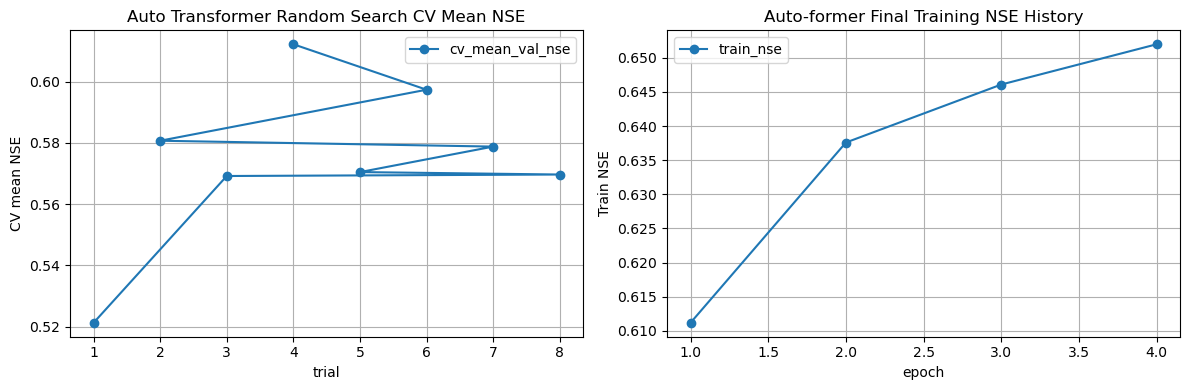

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

search_results_df.plot(
    x="trial",
    y="cv_mean_val_nse",
    marker="o",
    ax=axes[0],
)

axes[0].set_title("Auto Transformer Random Search CV Mean NSE")
axes[0].set_ylabel("CV mean NSE")
axes[0].grid(True)

final_history_df.plot(
    x="epoch",
    y="train_nse",
    marker="o",
    ax=axes[1],
)

axes[1].set_title("Auto-former Final Training NSE History")
axes[1].set_ylabel("Train NSE")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
from pathlib import Path
import sys, math
import numpy as np
import torch

# ====== BASIC METRICS ======

def global_metrics(true, pred):
    diff = pred - true
    mse = float(np.mean(diff * diff))
    rmse = math.sqrt(max(mse, 0.0))
    mae = float(np.mean(np.abs(diff)))

    sse = float(np.sum(diff * diff))
    centered = true - float(np.mean(true))
    sst = float(np.sum(centered * centered))

    nse = 1.0 - sse / sst if sst > 1e-12 else float("nan")

    return {"rmse": rmse, "mae": mae, "nse": nse}


def per_basin_nse(true, pred, basin_slots, basin_ids):
    n_basins = int(np.max(basin_slots)) + 1
    scores = np.full(n_basins, np.nan)

    rows = []

    for slot in range(n_basins):
        mask = basin_slots == slot
        if np.sum(mask) < 2:
            continue

        y = true[mask]
        y_hat = pred[mask]

        sst = np.sum((y - np.mean(y)) ** 2)
        if sst <= 1e-12:
            continue

        score = 1.0 - np.sum((y - y_hat) ** 2) / sst
        scores[slot] = score

        rows.append({
            "basin_slot": slot,
            "basin_id": basin_ids[slot],
            "nse": score,
        })

    rows.sort(key=lambda x: x["nse"])
    return scores, rows


def clipped_per_basin_nse(scores):
    finite = scores[np.isfinite(scores)]
    if len(finite) == 0:
        return finite, None, None, 0, 0

    x_min = max(np.percentile(finite, 2), -1.0)
    x_max = min(np.percentile(finite, 98), 1.0)

    clipped = np.clip(finite, x_min, x_max)

    return clipped, x_min, x_max, 0, 0

In [31]:

class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        pad = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, pad, 1)
        end = x[:, -1:, :].repeat(1, pad, 1)
        x_pad = torch.cat([front, x, end], dim=1)

        # AvgPool1d expects (B, C, L)
        trend = self.avg(x_pad.transpose(1, 2)).transpose(1, 2)
        return trend


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_avg = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

class AutoCorrelationAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, factor=1):
        super().__init__()
        assert d_model % nhead == 0

        self.d_model = d_model
        self.nhead = nhead
        self.d_head = d_model // nhead
        self.factor = factor

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, L, D)
        B, L, D = x.shape
        H = self.nhead
        Dh = self.d_head

        q = self.q_proj(x).view(B, L, H, Dh).transpose(1, 2)  # (B,H,L,Dh)
        k = self.k_proj(x).view(B, L, H, Dh).transpose(1, 2)
        v = self.v_proj(x).view(B, L, H, Dh).transpose(1, 2)

        # FFT autocorrelation: much faster than looping over all delays
        q_fft = torch.fft.rfft(q, dim=2)
        k_fft = torch.fft.rfft(k, dim=2)
        corr = torch.fft.irfft(q_fft * torch.conj(k_fft), n=L, dim=2)

        # Average over feature dim -> (B,H,L)
        corr_score = corr.mean(dim=-1)

        # Autoformer-style top-k delays
        top_k = max(1, int(self.factor * math.log(L)))
        top_k = min(top_k, L)

        # Average over batch and heads -> global top-k delays
        mean_corr = corr_score.mean(dim=(0, 1))  # (L,)
        weights, delays = torch.topk(mean_corr, top_k, dim=0)  # (K,)
        weights = torch.softmax(weights, dim=0)
        
        out = torch.zeros_like(v)
        
        for i in range(top_k):
            delay = int(delays[i].item())
            shifted = torch.roll(v, shifts=-delay, dims=2)
            out = out + shifted * weights[i]

        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.out_proj(self.dropout(out))

    @staticmethod
    def batch_roll(x, shifts):
        """
        x:      (B, H, L, Dh)
        shifts: (B, H)
        """
        B, H, L, Dh = x.shape

        idx = torch.arange(L, device=x.device).view(1, 1, L)
        shifts = shifts.unsqueeze(-1)

        gather_idx = (idx - shifts) % L
        gather_idx = gather_idx.unsqueeze(-1).expand(B, H, L, Dh)

        return torch.gather(x, dim=2, index=gather_idx)


class AutoformerLiteEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout, moving_avg_kernel):
        super().__init__()

        self.decomp1 = SeriesDecomposition(moving_avg_kernel)
        self.decomp2 = SeriesDecomposition(moving_avg_kernel)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = x + self.dropout(attn_out)

        seasonal, trend1 = self.decomp1(x)

        ffn_out = self.ffn(seasonal)
        x = seasonal + self.dropout(ffn_out)

        seasonal, trend2 = self.decomp2(x)

        return seasonal + trend1 + trend2


class TemporalSummaryAutoformer(nn.Module):
    def __init__(
        self,
        seq_len: int,
        num_dynamic_features: int,
        num_basins: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float,
        moving_avg_kernel: int = 25,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.num_dynamic_features = num_dynamic_features

        self.input_projection = nn.Linear(num_dynamic_features, d_model)

        self.position_embedding = nn.Parameter(
            torch.randn(1, seq_len, d_model) * 0.02
        )

        self.basin_embedding = nn.Embedding(num_basins, d_model)

        self.layers = nn.ModuleList([
            AutoformerLiteEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                moving_avg_kernel=moving_avg_kernel,
            )
            for _ in range(num_layers)
        ])

        # same summary idea: last + mean7 + mean30 + mean90 + mean365
        self.summary_len = d_model * 5

        self.head = nn.Sequential(
            nn.LayerNorm(self.summary_len + d_model),
            nn.Linear(self.summary_len + d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, max(1, d_model // 2)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(1, d_model // 2), 1),
        )

    def forward(self, x_dynamic: torch.Tensor, basin_code: torch.Tensor) -> torch.Tensor:
        # x_dynamic: (B, L, C)
        B, L, C = x_dynamic.shape

        if L != self.seq_len:
            raise ValueError(f"Expected seq_len={self.seq_len}, got {L}")

        if C != self.num_dynamic_features:
            raise ValueError(
                f"Expected num_dynamic_features={self.num_dynamic_features}, got {C}"
            )

        basin_code = basin_code.long().view(-1)

        x = self.input_projection(x_dynamic)
        x = x + self.position_embedding

        for layer in self.layers:
            x = layer(x)

        last_value = x[:, -1, :]
        mean_7 = x[:, -7:, :].mean(dim=1)
        mean_30 = x[:, -30:, :].mean(dim=1)
        mean_90 = x[:, -90:, :].mean(dim=1)
        mean_365 = x.mean(dim=1)

        temporal_summary = torch.cat(
            [last_value, mean_7, mean_30, mean_90, mean_365],
            dim=-1,
        )

        basin_repr = self.basin_embedding(basin_code)

        out = torch.cat([basin_repr, temporal_summary], dim=-1)

        return self.head(out).squeeze(-1)

In [32]:
def read_joined_table(data_dir, config, feature_columns, target_column):
    preferences = config.get(
        "JOINED_FILENAME_PREFERENCE",
        ["camels_transformer_joined.parquet", "camels_transformer_joined.csv"],
    )

    joined_path = None
    for name in preferences:
        candidate = data_dir / name
        if candidate.exists():
            joined_path = candidate
            break

    if joined_path is None:
        raise FileNotFoundError(f"Could not find joined table in {data_dir}")

    columns = ["basin_id", "date"] + list(feature_columns) + [target_column]
    columns = list(dict.fromkeys(columns))

    if joined_path.suffix == ".parquet":
        df = pd.read_parquet(joined_path, columns=columns)
    else:
        df = pd.read_csv(joined_path, usecols=columns, parse_dates=["date"])

    df["basin_id"] = df["basin_id"].astype(str).str.zfill(8)
    df["date"] = pd.to_datetime(df["date"])

    df = df.replace([-999, -999.0, -99, -99.0], np.nan)
    df = df.dropna(subset=list(feature_columns) + [target_column]).copy()
    df = df[df[target_column] >= 0].copy()

    return df.sort_values(["basin_id", "date"]).reset_index(drop=True)


def eligible_target_indices(n_rows, lookback_days, horizon_days):
    first_target_idx = lookback_days + horizon_days - 1

    if n_rows <= first_target_idx:
        return np.array([], dtype=np.int64)

    return np.arange(first_target_idx, n_rows, dtype=np.int64)


def build_holdout_target_map(
    basin_store,
    lookback_days,
    horizon_days,
    holdout_start,
    holdout_end,
):
    start = np.datetime64(holdout_start)
    end = np.datetime64(holdout_end)

    target_map = {}

    for basin_id, basin_data in basin_store.items():
        target_idx = eligible_target_indices(
            len(basin_data["dates"]),
            lookback_days,
            horizon_days,
        )

        target_dates = basin_data["dates"][target_idx].astype("datetime64[D]")
        mask = (target_dates >= start) & (target_dates <= end)

        if np.any(mask):
            target_map[basin_id] = target_idx[mask]

    return target_map


class ExternalWindowDataset(Dataset):
    def __init__(
        self,
        basin_store,
        target_map,
        lookback_days,
        horizon_days,
        feature_mean,
        feature_std,
        basin_id_to_slot,
    ):
        self.basin_store = basin_store
        self.lookback_days = int(lookback_days)
        self.horizon_days = int(horizon_days)
        self.feature_mean = feature_mean.astype(np.float32)
        self.feature_std = feature_std.astype(np.float32)
        self.basin_id_to_slot = basin_id_to_slot

        self.entries = []
        self.cum_counts = []

        running = 0

        for basin_id in sorted(target_map):
            target_indices = np.asarray(target_map[basin_id], dtype=np.int64)

            if len(target_indices) == 0:
                continue

            self.entries.append((basin_id, target_indices))
            running += len(target_indices)
            self.cum_counts.append(running)

        self.length = running

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        basin_pos = bisect_right(self.cum_counts, idx)
        basin_id, target_indices = self.entries[basin_pos]

        prev_count = 0 if basin_pos == 0 else self.cum_counts[basin_pos - 1]
        target_idx = int(target_indices[idx - prev_count])

        series = self.basin_store[basin_id]

        sequence_start = target_idx - self.horizon_days - self.lookback_days + 1
        sequence_end = sequence_start + self.lookback_days

        x = series["features"][sequence_start:sequence_end]
        x = (x - self.feature_mean) / self.feature_std

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.tensor(float(series["target"][target_idx]), dtype=torch.float32),
            "basin_code": torch.tensor(int(series["basin_code"]), dtype=torch.long),
            "basin_slot": torch.tensor(self.basin_id_to_slot[basin_id], dtype=torch.long),
            "target_date": str(np.datetime_as_string(series["dates"][target_idx], unit="D")),
        }


def collate(batch):
    return {
        "x": torch.stack([item["x"] for item in batch]),
        "y": torch.stack([item["y"] for item in batch]),
        "basin_code": torch.stack([item["basin_code"] for item in batch]),
        "basin_slot": torch.stack([item["basin_slot"] for item in batch]),
        "target_date": [str(item["target_date"]) for item in batch],
    }

In [33]:
DATA_DIR = Path(r"C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\processed")
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

print("checkpoint keys:")
print(checkpoint.keys())

config = checkpoint.get("config", {})

lookback_days = int(config.get("LOOKBACK_DAYS", 365))
horizon_days = int(config.get("PREDICTION_HORIZON_DAYS", 1))

print("lookback_days:", lookback_days)
print("horizon_days:", horizon_days)

feature_columns = list(checkpoint["feature_columns"])
target_column = str(checkpoint["target_column"])

dynamic_feature_columns = list(
    checkpoint.get("dynamic_feature_columns", feature_columns)
)

basin_code_column = str(checkpoint.get("basin_code_column", "basin_code"))

used_feature_columns = dynamic_feature_columns

print("target_column:", target_column)
print("n used features:", len(used_feature_columns))
print("basin_code_column:", basin_code_column)
print("best_hparams:", checkpoint["best_hparams"])

read_columns = list(used_feature_columns) + [basin_code_column]

df = read_joined_table(
    DATA_DIR,
    config,
    feature_columns=read_columns,
    target_column=target_column,
)

basin_store = {}
basin_ids = []

for basin_id, basin_df in df.groupby("basin_id", sort=True):
    basin_df = basin_df.sort_values("date").reset_index(drop=True)
    basin_ids.append(str(basin_id))

    basin_code_values = basin_df[basin_code_column].unique()

    if len(basin_code_values) != 1:
        raise ValueError(f"Basin {basin_id} has multiple basin_code values.")

    basin_store[str(basin_id)] = {
        "features": basin_df[used_feature_columns].to_numpy(dtype=np.float32),
        "basin_code": int(basin_code_values[0]),
        "target": basin_df[target_column].to_numpy(dtype=np.float32),
        "dates": basin_df["date"].to_numpy(),
    }

target_map = build_holdout_target_map(
    basin_store,
    lookback_days=lookback_days,
    horizon_days=horizon_days,
    holdout_start=config.get("INDEPENDENT_VAL_START", "2008-01-01"),
    holdout_end=config.get("INDEPENDENT_VAL_END", "2014-12-31"),
)

basin_id_to_slot = {basin_id: idx for idx, basin_id in enumerate(basin_ids)}

dataset = ExternalWindowDataset(
    basin_store=basin_store,
    target_map=target_map,
    lookback_days=lookback_days,
    horizon_days=horizon_days,
    feature_mean=np.asarray(checkpoint["feature_mean"], dtype=np.float32),
    feature_std=np.asarray(checkpoint["feature_std"], dtype=np.float32),
    basin_id_to_slot=basin_id_to_slot,
)

print("n basins:", len(basin_ids))
print("n holdout samples:", len(dataset))

checkpoint keys:
dict_keys(['model_state_dict', 'feature_columns', 'dynamic_feature_columns', 'basin_code_column', 'target_column', 'feature_mean', 'feature_std', 'best_hparams', 'config', 'holdout_metrics', 'num_basins'])
lookback_days: 365
horizon_days: 1
target_column: QObs(mm/day)
n used features: 9
basin_code_column: basin_code
best_hparams: {'batch_size': 16.0, 'd_model': 96.0, 'dim_feedforward': 128.0, 'dropout': 0.1, 'learning_rate': 0.0003, 'moving_avg_kernel': 7.0, 'nhead': 4.0, 'num_layers': 1.0, 'weight_decay': 0.0, 'trial': 4.0, 'elapsed_sec': 640.4282178878784, 'cv_mean_best_epoch': 4.25, 'cv_mean_val_nse': 0.6122404783964157, 'cv_std_val_nse': 0.020062968823636663, 'cv_mean_val_rmse': 2.1865400075912476, 'cv_mean_val_mae': 0.6830878555774689}
n basins: 671
n holdout samples: 1648382


In [35]:
h = checkpoint["best_hparams"]
device = CONFIG["DEVICE"]
model = TemporalSummaryAutoformer(
    seq_len=lookback_days,
    num_dynamic_features=len(used_feature_columns),
    num_basins=int(checkpoint["num_basins"]),
    d_model=int(h["d_model"]),
    nhead=int(h["nhead"]),
    num_layers=int(h["num_layers"]),
    dim_feedforward=int(h["dim_feedforward"]),
    dropout=float(h["dropout"]),
    moving_avg_kernel=int(h.get("moving_avg_kernel", 25)),
).to( device )

missing, unexpected = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=False,
)

print("missing keys:", missing)
print("unexpected keys:", unexpected)

if missing or unexpected:
    print("WARNING: model definition may not exactly match training.")

model.eval()

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate,
)

pred_parts = []
true_parts = []
slot_parts = []
date_parts = []

with torch.no_grad():
    for batch in loader:
        x = batch["x"].to(device)
        basin_code = batch["basin_code"].to(device)

        y_hat = model(x, basin_code)

        pred_parts.append(y_hat.detach().cpu().numpy().reshape(-1))
        true_parts.append(batch["y"].cpu().numpy().reshape(-1))
        slot_parts.append(batch["basin_slot"].cpu().numpy().reshape(-1))
        date_parts.extend(batch["target_date"])

pred = np.concatenate(pred_parts)
true = np.concatenate(true_parts)
basin_slots = np.concatenate(slot_parts).astype(np.int64)
dates = np.asarray(date_parts)

scores, rows = per_basin_nse(true, pred, basin_slots, basin_ids)
metrics = global_metrics(true, pred)
clipped_scores, _, _, _, _ = clipped_per_basin_nse(scores)

print(
    f"autoformer {SPLIT_NAME.upper()} | "
    f"RMSE={metrics['rmse']:.4f} "
    f"MAE={metrics['mae']:.4f} "
    f"Global_NSE={metrics['nse']:.4f} "
    f"clipped_mean_basin_NSE={float(np.mean(clipped_scores)):.4f} "
    f"clipped_median_basin_NSE={float(np.median(clipped_scores)):.4f}"
)

missing keys: []
unexpected keys: []
autoformer TEST | RMSE=2.3100 MAE=0.6199 Global_NSE=0.6035 clipped_mean_basin_NSE=0.4253 clipped_median_basin_NSE=0.4809


Saved: model_artifacts\your_run\figures\test_autoformer_predictions.csv


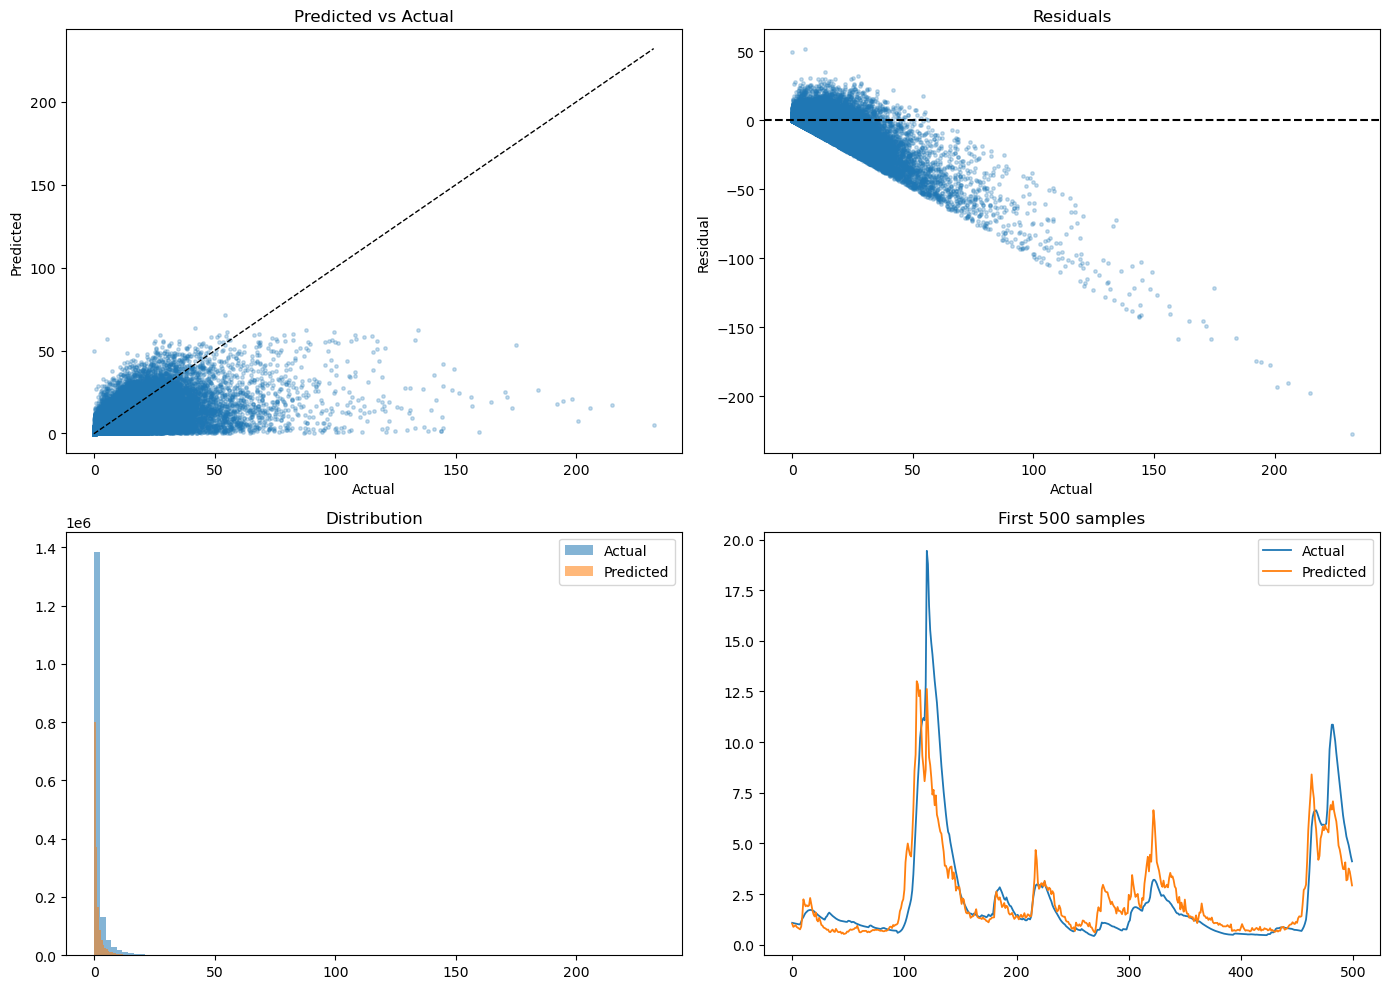

Saved: model_artifacts\your_run\figures\test_autoformer_predictions.png


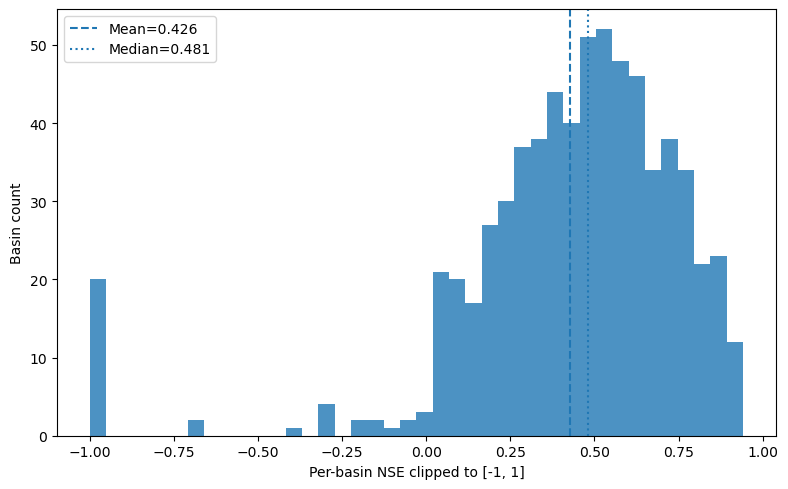

Saved: model_artifacts\your_run\figures\test_autoformer_predictions_per_basin_nse_distribution.png


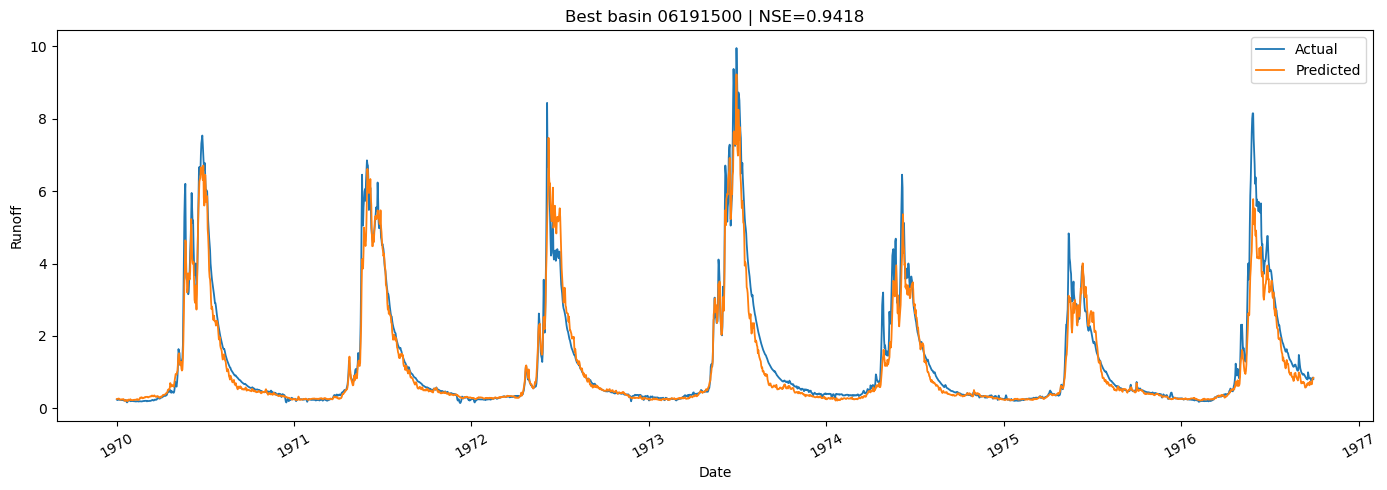

Saved: model_artifacts\your_run\figures\test_autoformer_predictions_best_basin_06191500.png
All outputs saved to: model_artifacts\your_run\figures


In [40]:
import matplotlib.dates as mdates
def save_predictions_csv(path, true, pred, basin_slots, dates, basin_ids):
    import pandas as pd
    
    rows = []
    for i in range(len(true)):
        slot = int(basin_slots[i])
        
        rows.append({
            "target_date": dates[i] if dates is not None else "",
            "basin_slot": slot,
            "basin_id": basin_ids[slot],
            "actual": float(true[i]),
            "predicted": float(pred[i]),
        })
    
    df = pd.DataFrame(rows)
    df.to_csv(path, index=False)
    print("Saved:", path)

import numpy as np
import matplotlib.pyplot as plt

def plot_predictions_simple(output_path, true, pred, scores=None, n_plot=500):
    residuals = pred - true

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    lo = float(min(np.min(true), np.min(pred)))
    hi = float(max(np.max(true), np.max(pred)))

    axes[0, 0].scatter(true, pred, s=6, alpha=0.25)
    axes[0, 0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
    axes[0, 0].set_xlabel("Actual")
    axes[0, 0].set_ylabel("Predicted")
    axes[0, 0].set_title("Predicted vs Actual")

    axes[0, 1].scatter(true, residuals, s=6, alpha=0.25)
    axes[0, 1].axhline(0, color="black", linestyle="--")
    axes[0, 1].set_xlabel("Actual")
    axes[0, 1].set_ylabel("Residual")
    axes[0, 1].set_title("Residuals")

    bins = min(100, max(20, int(np.sqrt(len(true)))))
    axes[1, 0].hist(true, bins=bins, alpha=0.55, label="Actual")
    axes[1, 0].hist(pred, bins=bins, alpha=0.55, label="Predicted")
    axes[1, 0].legend()
    axes[1, 0].set_title("Distribution")

    n = min(n_plot, len(true))
    axes[1, 1].plot(true[:n], label="Actual", linewidth=1.3)
    axes[1, 1].plot(pred[:n], label="Predicted", linewidth=1.3)
    axes[1, 1].legend()
    axes[1, 1].set_title(f"First {n} samples")

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def plot_per_basin_nse_distribution_simple(output_path, scores):
    finite = scores[np.isfinite(scores)]

    if finite.size == 0:
        print("No finite basin NSE.")
        return

    clipped = np.clip(finite, -1.0, 1.0)

    plt.figure(figsize=(8, 5))
    plt.hist(clipped, bins=40, alpha=0.8)
    plt.axvline(np.mean(clipped), linestyle="--", label=f"Mean={np.mean(clipped):.3f}")
    plt.axvline(np.median(clipped), linestyle=":", label=f"Median={np.median(clipped):.3f}")
    plt.xlabel("Per-basin NSE clipped to [-1, 1]")
    plt.ylabel("Basin count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

output_base = OUTPUT_DIR / f"{SPLIT_NAME}_autoformer_predictions"

save_predictions_csv(
    output_base.with_suffix(".csv"),
    true,
    pred,
    basin_slots,
    dates,
    basin_ids,
)

plot_predictions_simple(
    output_base.with_suffix(".png"),
    true,
    pred,
    scores,
    n_plot=500,
)

plot_per_basin_nse_distribution_simple(
    output_base.with_name(f"{output_base.name}_per_basin_nse_distribution.png"),
    scores,
)

# Best basin time-series plot
if rows:
    best_row = rows[-1]
    best_slot = int(best_row["basin_slot"])
    best_basin_id = str(best_row["basin_id"])

    mask = basin_slots == best_slot
    order = np.argsort(dates[mask].astype("datetime64[D]"))

    best_dates = dates[mask][order]
    best_true = true[mask][order]
    best_pred = pred[mask][order]

    plt.figure(figsize=(14, 5))
    
    plt.plot(best_dates, best_true, label="Actual", linewidth=1.3)
    plt.plot(best_dates, best_pred, label="Predicted", linewidth=1.3)
    
    plt.title(f"Best basin {best_basin_id} | NSE={best_row['nse']:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Runoff")
    plt.legend()
    
    # 🔥 KEY FIX: only show years
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    
    best_path = output_base.with_name(
        f"{output_base.name}_best_basin_{best_basin_id}.png"
    )
    
    plt.savefig(best_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print("Saved:", best_path)
    
    print("All outputs saved to:", OUTPUT_DIR)

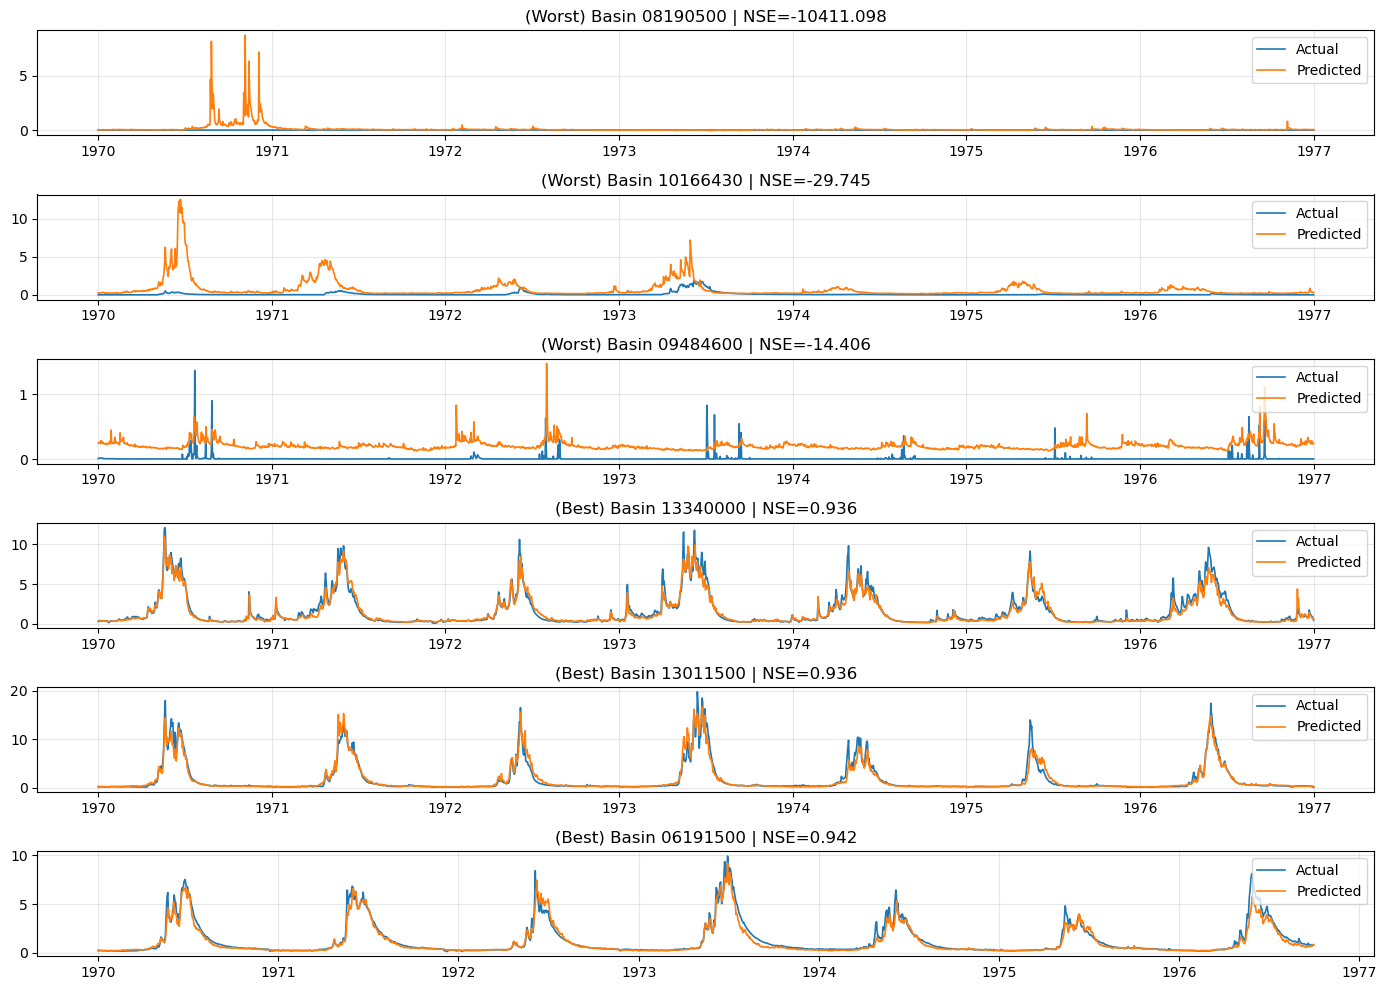

Saved: model_artifacts\your_run\figures\test_autoformer_predictions_best_worst_basins.png


In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n_each = 3

worst = rows[:n_each]
best = rows[-n_each:]

selected = worst + best

fig, axes = plt.subplots(len(selected), 1, figsize=(14, 10), sharex=False)

for i, row in enumerate(selected):
    slot = int(row["basin_slot"])
    basin_id = row["basin_id"]
    nse = row["nse"]

    mask = basin_slots == slot
    order = np.argsort(dates[mask].astype("datetime64[D]"))

    d = dates[mask][order]
    y = true[mask][order]
    y_hat = pred[mask][order]

    ax = axes[i]

    ax.plot(d, y, label="Actual", linewidth=1.2)
    ax.plot(d, y_hat, label="Predicted", linewidth=1.2)

    if i < n_each:
        ax.set_title(f"(Worst) Basin {basin_id} | NSE={nse:.3f}")
    else:
        ax.set_title(f"(Best) Basin {basin_id} | NSE={nse:.3f}")

    # year ticks only
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

multi_path = output_base.with_name(f"{output_base.name}_best_worst_basins.png")
plt.savefig(multi_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", multi_path)

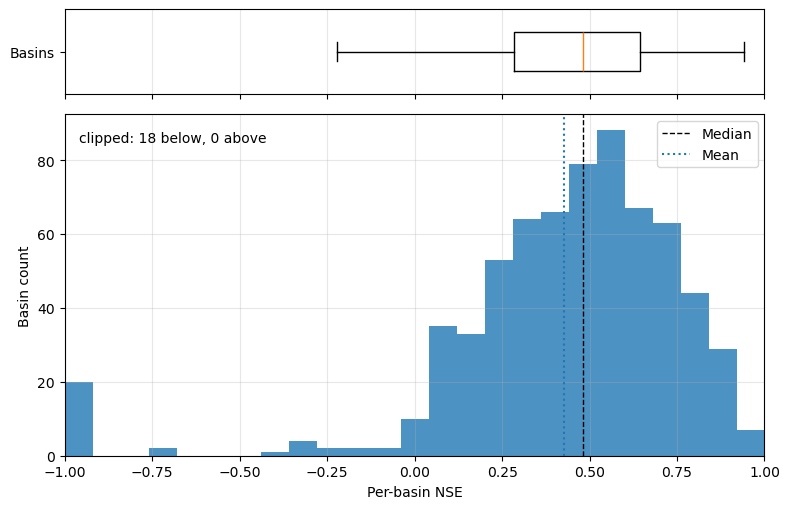

Saved: model_artifacts\your_run\figures\test_autoformer_predictions_per_basin_nse_distribution.png


In [43]:
def plot_per_basin_nse_distribution_simple(output_path, scores):
    import numpy as np
    import matplotlib.pyplot as plt

    finite = scores[np.isfinite(scores)]
    if finite.size == 0:
        print("No finite basin NSE.")
        return

    x_min, x_max = -1.0, 1.0
    n_below = int(np.sum(finite < x_min))
    n_above = int(np.sum(finite > x_max))
    clipped = np.clip(finite, x_min, x_max)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 5.2),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 4]},
    )

    # Top: horizontal boxplot
    axes[0].boxplot(
        clipped,
        vert=False,
        widths=0.45,
        showfliers=False,
    )
    axes[0].set_yticks([1])
    axes[0].set_yticklabels(["Basins"])
    axes[0].grid(True, axis="x", alpha=0.3)

    # Bottom: histogram
    bins = min(60, max(15, int(np.sqrt(clipped.size))))
    axes[1].hist(clipped, bins=bins, range=(x_min, x_max), alpha=0.8)

    median_score = float(np.median(clipped))
    mean_score = float(np.mean(clipped))

    axes[1].axvline(median_score, color="black", linestyle="--", linewidth=1, label="Median")
    axes[1].axvline(mean_score, linestyle=":", linewidth=1.5, label="Mean")

    if n_below or n_above:
        axes[1].text(
            0.02,
            0.95,
            f"clipped: {n_below} below, {n_above} above",
            transform=axes[1].transAxes,
            va="top",
            ha="left",
            fontsize=10,
        )

    axes[1].set_xlim(x_min, x_max)
    axes[1].set_xlabel("Per-basin NSE")
    axes[1].set_ylabel("Basin count")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)
plot_per_basin_nse_distribution_simple(
    output_base.with_name(f"{output_base.name}_per_basin_nse_distribution.png"),
    scores,
)